In [1]:
! pip install feature_engine==1.8.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.1/357.1 kB 28.8 MB/s eta 0:00:00


In [2]:
!pip install optuna==4.8.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.4 MB/s eta 0:00:00


In [3]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.5.2 -q

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 114.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [4]:
# !pip uninstall lightgbm -y
!pip install lightgbm

In [5]:
import torch
print(torch.cuda.is_available()) # Deve retornar True no Colab com GPU ativa

True


In [6]:
import pandas as pd
import numpy as np
import sys
import os
import gc

import unicodedata
import re

import seaborn as sns
import matplotlib.pyplot as plt

import feature_engine
from feature_engine.selection import (
    RecursiveFeatureElimination,
    DropConstantFeatures,
    DropDuplicateFeatures,
)
import optuna

from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.preprocessing import StandardScaler
import sklearn

import xgboost
import lightgbm
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import time

import tensorflow as tf
print(tf.__version__)

print(f"Versão:")
print(f'Python: {sys.version}')
print(f'Pandas: {pd.__version__}')
print(f'Numpy: {np.__version__}')
print("Feature Engine:", feature_engine.__version__)
print("Scikit-Learn:", sklearn.__version__)
print("Optuna:", optuna.__version__)
print("XGBoost:", xgboost.__version__)
print("LightGBM:", lightgbm.__version__)
print("Tensorflow", tf.__version__)

2.20.0
Versão:
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas: 2.2.2
Numpy: 2.0.2
Feature Engine: 1.8.0
Scikit-Learn: 1.5.2
Optuna: 4.8.0
XGBoost: 3.2.0
LightGBM: 4.6.0
Tensorflow 2.20.0


In [7]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
path_main = '/content/drive/MyDrive/ML-UFF'

Mounted at /content/drive


In [8]:
def get_data_frame(path_dataset: str):
  data = pd.read_csv(path_dataset)
  return data

In [9]:
path = f'{path_main}/df_feat.csv'
df = get_data_frame(path)

In [10]:
df['data'] = pd.to_datetime(df['data'])
df.set_index('data', inplace=True)

In [11]:
df.shape, df.columns

((2245, 66),
 Index(['total_casos', 'score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia',
        'temp_min_dia', 'umidade_dia', 'year', 'month', 'day_week',
        'chuva_acum_7d', 'gravidade_lag_7d', 'chuva_acum_15d',
        'gravidade_lag_15d', 'chuva_acum_21d', 'gravidade_lag_21d',
        'chuva_acum_30d', 'gravidade_lag_30d', 'chuva_acum_45d',
        'gravidade_lag_45d', 'chuva_acum_50d', 'gravidade_lag_50d',
        'chuva_acum_60d', 'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d',
        'casos_mm21d', 'casos_mm30d', 'casos_mm45d', 'casos_mm50d',
        'casos_mm60d', 'temp_min_lag_7d', 'temp_min_lag_15d',
        'temp_min_lag_21d', 'temp_min_lag_30d', 'temp_min_lag_45d',
        'temp_min_lag_50d', 'temp_min_lag_60d', 'temp_max_lag_7d',
        'temp_max_lag_15d', 'temp_max_lag_21d', 'temp_max_lag_30d',
        'temp_max_lag_45d', 'temp_max_lag_50d', 'temp_max_lag_60d',
        'faixa_chuva', 'faixa_umidade', 'day_month', 'day_month_start',
        'day_month_end', '

In [12]:
def print_nan(df):
    nan_count = df.isna().sum()
    # Filtra apenas onde a contagem é maior que zero
    nan_only = nan_count[nan_count > 0].sort_values(ascending=False)

    if nan_only.empty:
        print("Nenhum valor NaN encontrado!")
    else:
        print("Colunas com valores NaN:")
        print(nan_only)

In [13]:
print_nan(df)

Nenhum valor NaN encontrado!


### Train Test Split

In [14]:
# Separar o df
def train_test_split_by_date(
    data: pd.DataFrame | pd.Series,
    start_date: str,
    split_date: str,
    end_date: str | None = None,
):
    if not isinstance(data.index, pd.DatetimeIndex):
        raise ValueError("data must have a DatetimeIndex")

    # garantir ordem temporal
    data = data.sort_index()

    start_date = pd.to_datetime(start_date)
    split_date = pd.to_datetime(split_date)
    end_date = pd.to_datetime(end_date) if end_date else data.index.max()

    if not (start_date < split_date < end_date):
        raise ValueError("start_date < split_date < end_date is required")

    # 🔑 slicing robusto (não depende da data existir no índice)
    start_pos = data.index.searchsorted(start_date, side="left")
    end_pos = data.index.searchsorted(end_date, side="right")

    data = data.iloc[start_pos:end_pos]

    split_pos = data.index.searchsorted(split_date, side="right")
    train = data.iloc[:split_pos]
    test = data.iloc[split_pos:]

    return train, test

In [15]:
start_date = df.index.min().strftime('%Y-%m-%d')
split_date_test = '2025-12-24' # 60 dias maior lag gerado
split_date_validation = '2025-08-26' # 60 dias
end_date = df.index.max().strftime('%Y-%m-%d')

start_date, split_date_validation, split_date_test, end_date

('2020-03-01', '2025-08-26', '2025-12-24', '2026-04-23')

In [16]:
df_train_temp, df_test = train_test_split_by_date(df, start_date, split_date_test, end_date)

In [17]:
df_train, df_val = train_test_split_by_date(df_train_temp, start_date, split_date_validation, split_date_test)

In [18]:
df_train.shape, df_train.index.unique()

((2005, 66),
 DatetimeIndex(['2020-03-01', '2020-03-02', '2020-03-03', '2020-03-04',
                '2020-03-05', '2020-03-06', '2020-03-07', '2020-03-08',
                '2020-03-09', '2020-03-10',
                ...
                '2025-08-17', '2025-08-18', '2025-08-19', '2025-08-20',
                '2025-08-21', '2025-08-22', '2025-08-23', '2025-08-24',
                '2025-08-25', '2025-08-26'],
               dtype='datetime64[ns]', name='data', length=2005, freq=None))

In [19]:
df_val.shape, df_val.index.unique()

((120, 66),
 DatetimeIndex(['2025-08-27', '2025-08-28', '2025-08-29', '2025-08-30',
                '2025-08-31', '2025-09-01', '2025-09-02', '2025-09-03',
                '2025-09-04', '2025-09-05',
                ...
                '2025-12-15', '2025-12-16', '2025-12-17', '2025-12-18',
                '2025-12-19', '2025-12-20', '2025-12-21', '2025-12-22',
                '2025-12-23', '2025-12-24'],
               dtype='datetime64[ns]', name='data', length=120, freq=None))

In [20]:
df_test.shape, df_test.index.unique()

((120, 66),
 DatetimeIndex(['2025-12-25', '2025-12-26', '2025-12-27', '2025-12-28',
                '2025-12-29', '2025-12-30', '2025-12-31', '2026-01-01',
                '2026-01-02', '2026-01-03',
                ...
                '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17',
                '2026-04-18', '2026-04-19', '2026-04-20', '2026-04-21',
                '2026-04-22', '2026-04-23'],
               dtype='datetime64[ns]', name='data', length=120, freq=None))

In [21]:
df_train.describe()

,total_casos,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
count,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,...,2005.000000,2.005000e+03,2005.000000,2.005000e+03,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2.005000e+03
mean,44.942643,11.634130,30.729394,11.804140,30.199594,18.566284,78.124558,2022.415960,6.426434,2.999002,...,-0.000062,2.698475e-04,0.000360,-1.735400e-04,-0.001930,0.001402,0.001745,0.057908,-0.001244,7.505943e-05
std,129.641138,0.274246,8.451706,33.359878,4.177824,3.094147,7.382627,1.612868,3.344522,2.001745,...,0.707411,7.071557e-01,0.707530,7.070360e-01,0.707053,0.707509,0.706841,0.705349,0.706845,7.077203e-01
min,0.000000,9.000000,0.000000,0.000000,18.700000,8.300000,39.593750,2020.000000,1.000000,0.000000,...,-0.900969,-9.749279e-01,-0.900969,-9.749279e-01,-1.000000,-0.994522,-0.999963,-0.999991,-0.999963,-9.999907e-01
25%,3.000000,11.517241,26.666667,0.000000,27.100000,16.400000,73.958333,2021.000000,4.000000,1.000000,...,-0.900969,-7.818315e-01,-0.900969,-7.818315e-01,-0.669131,-0.743145,-0.708627,-0.648630,-0.708627,-7.055836e-01
50%,11.000000,11.625000,30.363636,0.200000,30.200000,19.000000,78.468750,2022.000000,6.000000,3.000000,...,-0.222521,-4.311252e-14,-0.222521,-6.073010e-14,-0.104528,0.000000,0.004304,0.128748,0.004304,2.572996e-15
75%,35.000000,11.765957,33.924781,6.200000,33.300000,21.000000,83.171875,2024.000000,9.000000,5.000000,...,0.623490,7.818315e-01,0.623490,7.818315e-01,0.669131,0.743145,0.702527,0.752667,0.702527,7.055836e-01
max,1501.000000,12.000000,68.000000,520.600000,42.500000,25.400000,95.359375,2025.000000,12.000000,6.000000,...,1.000000,9.749279e-01,1.000000,9.749279e-01,1.000000,0.994522,1.000000,0.999991,1.000000,9.999907e-01


In [22]:
df_val.describe()

,total_casos,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.0,120.000000,120.000000,...,120.000000,1.200000e+02,120.000000,1.200000e+02,1.200000e+02,1.200000e+02,120.000000,120.000000,120.000000,120.000000
mean,7.366667,11.573481,28.250134,8.280000,30.158333,18.225000,77.165972,2025.0,10.316667,2.991667,...,0.005196,-6.515262e-03,-0.001854,8.124399e-03,-1.580911e-16,-2.914335e-17,-0.462306,-0.691084,-0.162612,0.393777
std,2.857787,0.179567,6.356627,18.324496,4.261762,2.414426,8.187556,0.0,1.173828,2.002082,...,0.709394,7.106995e-01,0.707398,7.126856e-01,7.100716e-01,7.100716e-01,0.454632,0.323388,0.741514,0.524911
min,2.000000,11.142857,14.305556,0.000000,21.500000,12.100000,51.916667,2025.0,8.000000,0.000000,...,-0.900969,-9.749279e-01,-0.900969,-9.749279e-01,-1.000000e+00,-9.945219e-01,-0.999963,-0.999991,-0.999963,-0.763889
25%,5.000000,11.500000,24.809524,0.000000,27.175000,16.825000,72.373698,2025.0,9.000000,1.000000,...,-0.900969,-7.818315e-01,-0.900969,-7.818315e-01,-6.691306e-01,-7.431448e-01,-0.891957,-0.966289,-0.867432,0.023667
50%,7.000000,11.563492,27.734848,0.200000,29.850000,18.400000,78.645833,2025.0,10.000000,3.000000,...,-0.222521,-1.724402e-13,-0.222521,-2.429798e-13,5.342948e-15,-1.225080e-14,-0.555997,-0.831140,-0.381633,0.512367
75%,9.000000,11.675000,31.664773,8.200000,32.900000,19.825000,82.998698,2025.0,11.000000,5.000000,...,0.623490,7.818315e-01,0.623490,7.818315e-01,6.691306e-01,7.431448e-01,-0.077384,-0.452060,0.591195,0.868519
max,16.000000,12.000000,52.166667,134.400000,40.000000,22.800000,95.046875,2025.0,12.000000,6.000000,...,1.000000,9.749279e-01,1.000000,9.749279e-01,1.000000e+00,9.945219e-01,0.421101,0.043022,0.999852,0.999991


In [23]:
df_test.describe()

,total_casos,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.0,...,120.000000,1.200000e+02,120.000000,1.200000e+02,1.200000e+02,1.200000e+02,120.000000,120.000000,120.000000,120.000000
mean,10.550000,11.592108,32.377215,23.183333,32.079583,21.496667,82.836634,2025.941667,2.966667,3.0,...,0.005196,6.515262e-03,-0.001854,-8.124399e-03,2.368476e-16,-4.584296e-16,0.827735,-0.078603,0.418417,-0.080191
std,5.327667,0.223171,7.406475,38.192116,3.607849,1.136184,8.548816,0.235355,2.496833,2.0,...,0.709394,7.106995e-01,0.707398,7.126856e-01,7.100716e-01,7.100716e-01,0.155771,0.535728,0.482546,0.769756
min,0.000000,11.000000,10.000000,0.000000,22.900000,17.500000,56.947917,2025.000000,1.000000,0.0,...,-0.900969,-9.749279e-01,-0.900969,-9.749279e-01,-1.000000e+00,-9.945219e-01,0.436651,-0.899631,-0.618671,-0.999917
25%,6.000000,11.491667,27.866667,0.000000,29.600000,21.100000,77.618490,2026.000000,1.000000,1.0,...,-0.900969,-7.818315e-01,-0.900969,-7.818315e-01,-6.691306e-01,-7.431448e-01,0.714673,-0.570226,0.021516,-0.866330
50%,10.000000,11.600000,31.538462,10.000000,31.750000,21.300000,84.578125,2026.000000,3.000000,3.0,...,-0.222521,-1.253939e-13,-0.222521,-2.057332e-13,1.219858e-14,-5.390303e-15,0.869589,-0.094533,0.512371,-0.188199
75%,14.000000,11.750000,36.000000,27.800000,35.025000,22.300000,91.055990,2026.000000,3.250000,5.0,...,0.623490,7.818315e-01,0.623490,7.818315e-01,6.691306e-01,7.431448e-01,0.966848,0.405414,0.869589,0.741139
max,25.000000,12.000000,62.666667,210.400000,40.800000,24.200000,96.015625,2026.000000,12.000000,6.0,...,1.000000,9.749279e-01,1.000000,9.749279e-01,1.000000e+00,9.945219e-01,1.000000,0.801361,1.000000,0.999917


In [24]:
print(f"Validação: {df_val.index.min()} até {df_val.index.max()} (Tamanho: {len(df_val)})")
print(f"Teste: {df_test.index.min()} até {df_test.index.max()} (Tamanho: {len(df_test)})")
print("Val e Test são iguais?", df_val.equals(df_test))

Validação: 2025-08-27 00:00:00 até 2025-12-24 00:00:00 (Tamanho: 120)
Teste: 2025-12-25 00:00:00 até 2026-04-23 00:00:00 (Tamanho: 120)
Val e Test são iguais? False


### Split

In [25]:
def split_target(df: pd.DataFrame, columns_target: str):
    y = df[columns_target]
    X = df.drop(columns=[columns_target])

    return X, y

In [26]:
column_target = 'total_casos'

In [27]:
X_train, y_train = split_target(df_train, column_target)
X_val, y_val = split_target(df_val, column_target)
X_test, y_test = split_target(df_test, column_target)

In [28]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
X_test.shape, y_test.shape

(2005, 65) (2005,)
(120, 65) (120,)


((120, 65), (120,))

In [29]:
y_train.isna().sum().sum(), y_val.isna().sum().sum(), y_test.isna().sum().sum()

(np.int64(0), np.int64(0), np.int64(0))

In [30]:
X_train.index, X_val.index, X_test.index

(DatetimeIndex(['2020-03-01', '2020-03-02', '2020-03-03', '2020-03-04',
                '2020-03-05', '2020-03-06', '2020-03-07', '2020-03-08',
                '2020-03-09', '2020-03-10',
                ...
                '2025-08-17', '2025-08-18', '2025-08-19', '2025-08-20',
                '2025-08-21', '2025-08-22', '2025-08-23', '2025-08-24',
                '2025-08-25', '2025-08-26'],
               dtype='datetime64[ns]', name='data', length=2005, freq=None),
 DatetimeIndex(['2025-08-27', '2025-08-28', '2025-08-29', '2025-08-30',
                '2025-08-31', '2025-09-01', '2025-09-02', '2025-09-03',
                '2025-09-04', '2025-09-05',
                ...
                '2025-12-15', '2025-12-16', '2025-12-17', '2025-12-18',
                '2025-12-19', '2025-12-20', '2025-12-21', '2025-12-22',
                '2025-12-23', '2025-12-24'],
               dtype='datetime64[ns]', name='data', length=120, freq=None),
 DatetimeIndex(['2025-12-25', '2025-12-26', '2025-12-

# Scaler

In [31]:
X_train.columns

Index(['score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia', 'temp_min_dia',
       'umidade_dia', 'year', 'month', 'day_week', 'chuva_acum_7d',
       'gravidade_lag_7d', 'chuva_acum_15d', 'gravidade_lag_15d',
       'chuva_acum_21d', 'gravidade_lag_21d', 'chuva_acum_30d',
       'gravidade_lag_30d', 'chuva_acum_45d', 'gravidade_lag_45d',
       'chuva_acum_50d', 'gravidade_lag_50d', 'chuva_acum_60d',
       'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d', 'casos_mm21d',
       'casos_mm30d', 'casos_mm45d', 'casos_mm50d', 'casos_mm60d',
       'temp_min_lag_7d', 'temp_min_lag_15d', 'temp_min_lag_21d',
       'temp_min_lag_30d', 'temp_min_lag_45d', 'temp_min_lag_50d',
       'temp_min_lag_60d', 'temp_max_lag_7d', 'temp_max_lag_15d',
       'temp_max_lag_21d', 'temp_max_lag_30d', 'temp_max_lag_45d',
       'temp_max_lag_50d', 'temp_max_lag_60d', 'faixa_chuva', 'faixa_umidade',
       'day_month', 'day_month_start', 'day_month_end', 'day_quarter_start',
       'day_quarter_end', 'day

In [32]:
fourier = X_train.filter(like='ciclo')
cols_fourier = fourier.columns.to_list()
cols_fourier

['ciclos_fourier_cos_p7_k1',
 'ciclos_fourier_sin_p7_k1',
 'ciclos_fourier_cos_p7_k2',
 'ciclos_fourier_sin_p7_k2',
 'ciclos_fourier_cos_p7_k3',
 'ciclos_fourier_sin_p7_k3',
 'ciclos_fourier_cos_p30_k1',
 'ciclos_fourier_sin_p30_k1',
 'ciclos_fourier_cos_p365_k1',
 'ciclos_fourier_sin_p365_k1',
 'ciclos_fourier_cos_p365_k2',
 'ciclos_fourier_sin_p365_k2']

In [33]:
X_train_fourier = X_train[cols_fourier]
X_val_fourier = X_val[cols_fourier]
X_test_fourier = X_test[cols_fourier]
X_test_fourier

,ciclos_fourier_cos_p7_k1,ciclos_fourier_sin_p7_k1,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
data,,,,,,,,,,,,
2025-12-25,-0.900969,-4.338837e-01,0.623490,7.818315e-01,-0.222521,-9.749279e-01,0.500000,-0.866025,0.436651,-0.899631,-0.618671,-0.785650
2025-12-26,-0.222521,-9.749279e-01,-0.900969,4.338837e-01,0.623490,7.818315e-01,0.669131,-0.743145,0.452072,-0.891981,-0.591261,-0.806480
2025-12-27,0.623490,-7.818315e-01,-0.222521,-9.749279e-01,-0.900969,-4.338837e-01,0.809017,-0.587785,0.467359,-0.884068,-0.563151,-0.826354
2025-12-28,1.000000,3.922831e-14,1.000000,7.845662e-14,1.000000,-5.644361e-13,0.913545,-0.406737,0.482508,-0.875892,-0.534373,-0.845249
2025-12-29,0.623490,7.818315e-01,-0.222521,9.749279e-01,-0.900969,4.338837e-01,0.978148,-0.207912,0.497513,-0.867456,-0.504961,-0.863142
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-19,1.000000,-7.837740e-14,1.000000,-1.567548e-13,1.000000,2.196152e-13,-0.500000,-0.866025,0.651899,0.758306,-0.150055,0.988678
2026-04-20,0.623490,7.818315e-01,-0.222521,9.749279e-01,-0.900969,4.338837e-01,-0.309017,-0.951057,0.638749,0.769415,-0.183998,0.982927
2026-04-21,-0.222521,9.749279e-01,-0.900969,-4.338837e-01,0.623490,-7.818315e-01,-0.104528,-0.994522,0.625411,0.780296,-0.217723,0.976011


In [34]:
X_train_s = X_train.drop(columns=cols_fourier)
X_val_s = X_val.drop(columns=cols_fourier)
X_test_s = X_test.drop(columns=cols_fourier)

In [35]:
X_train_s.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2005 entries, 2020-03-01 to 2025-08-26
Data columns (total 53 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   score_gravidade    2005 non-null   float64
 1   idade              2005 non-null   float64
 2   chuva_dia          2005 non-null   float64
 3   temp_max_dia       2005 non-null   float64
 4   temp_min_dia       2005 non-null   float64
 5   umidade_dia        2005 non-null   float64
 6   year               2005 non-null   int64  
 7   month              2005 non-null   int64  
 8   day_week           2005 non-null   int64  
 9   chuva_acum_7d      2005 non-null   float64
 10  gravidade_lag_7d   2005 non-null   float64
 11  chuva_acum_15d     2005 non-null   float64
 12  gravidade_lag_15d  2005 non-null   float64
 13  chuva_acum_21d     2005 non-null   float64
 14  gravidade_lag_21d  2005 non-null   float64
 15  chuva_acum_30d     2005 non-null   float64
 16  gravid

In [36]:
def encode_categorical_columns(df):
    df_encoded = df.copy()
    cat_cols = df_encoded.select_dtypes(include=['category', 'object']).columns

    for col in cat_cols:
        print(f"Transformando a coluna: {col}")
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

    return df_encoded

In [37]:
X_train_s = encode_categorical_columns(X_train_s)
X_val_s = encode_categorical_columns(X_val_s)
X_test_s = encode_categorical_columns(X_test_s)

Transformando a coluna: faixa_chuva
Transformando a coluna: faixa_umidade
Transformando a coluna: faixa_chuva
Transformando a coluna: faixa_umidade
Transformando a coluna: faixa_chuva
Transformando a coluna: faixa_umidade


In [38]:
scaler = StandardScaler()

In [39]:
X_train_scaled = scaler.fit_transform(X_train_s)
X_val_scaled = scaler.transform(X_val_s)
X_test_scaled = scaler.transform(X_test_s)

In [40]:
X_train_scaled_df = pd.DataFrame(X_train_scaled,
                                 columns=X_train_s.columns,
                                 index=X_train_s.index)

X_val_scaled_df = pd.DataFrame(X_val_scaled,
                                 columns=X_val_s.columns,
                                 index=X_val_s.index)

X_test_scaled_df = pd.DataFrame(X_test_scaled,
                                 columns=X_test_s.columns,
                                 index=X_test_s.index)

X_train_scaled_df

,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,chuva_acum_7d,...,temp_max_lag_60d,faixa_chuva,faixa_umidade,day_month,day_month_start,day_month_end,day_quarter_start,day_quarter_end,day_year_start,day_year_end
data,,,,,,,,,,,,,,,,,,,,,
2020-03-01,0.813390,-0.441369,15.255535,-1.436415,0.883732,1.937805,-1.498302,-1.024747,1.499564,4.710811,...,1.742544,0.499203,-1.369086,-1.672869,5.420220,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-02,0.118672,0.071475,1.403109,-1.460357,0.334171,1.731752,-1.498302,-1.024747,-1.498567,5.221635,...,0.488740,0.499203,-1.369086,-1.559105,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-03,0.773310,0.059337,0.029859,-0.550566,0.431152,0.932944,-1.498302,-1.024747,-0.998879,5.287261,...,-0.282832,0.499203,-1.369086,-1.445341,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-04,-0.124480,-1.104123,-0.263980,-0.694217,0.786751,0.615396,-1.498302,-1.024747,-0.499190,5.281940,...,-0.186385,0.499203,1.338922,-1.331577,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-05,0.339718,0.128857,-0.233996,-0.311147,-0.312372,0.175064,-1.498302,-1.024747,0.000498,4.840291,...,-0.138162,0.499203,1.338922,-1.217813,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-22,0.929176,-0.721900,-0.353931,0.598644,-0.829607,-0.166476,1.602540,0.470608,0.500187,-0.713138,...,0.874526,-0.392072,-0.466417,0.716174,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2025-08-23,-1.097085,0.515284,-0.353931,1.125366,-1.088224,-2.856456,1.602540,0.470608,0.999876,-0.734422,...,-1.006180,-0.392072,0.436253,0.829938,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2025-08-24,-0.286581,-0.572868,-0.353931,-0.311147,-0.635644,-0.558824,1.602540,0.470608,1.499564,-0.734422,...,-1.850087,-0.392072,-0.466417,0.943702,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05


In [41]:
X_train_scaled = pd.concat([X_train_scaled_df, X_train_fourier], axis=1)
X_val_scaled = pd.concat([X_val_scaled_df, X_val_fourier], axis=1)
X_test_scaled = pd.concat([X_test_scaled_df, X_test_fourier], axis=1)

In [42]:
X_train_scaled.shape, X_train.shape

((2005, 65), (2005, 65))

In [43]:
X_val_scaled.shape, X_val.shape

((120, 65), (120, 65))

In [44]:
X_test_scaled.shape, X_test.shape

((120, 65), (120, 65))

In [45]:
X_test_scaled.head()

,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,chuva_acum_7d,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
data,,,,,,,,,,,,,,,,,,,,,
2025-12-25,-0.124480,0.387072,-0.353931,2.106983,1.110023,-1.153696,1.60254,1.666892,0.000498,-0.562374,...,0.623490,7.818315e-01,-0.222521,-9.749279e-01,0.500000,-0.866025,0.436651,-0.899631,-0.618671,-0.785650
2025-12-26,-0.749726,-0.397693,-0.353931,1.771796,0.883732,-0.496726,1.60254,1.666892,0.500187,-0.729101,...,-0.900969,4.338837e-01,0.623490,7.818315e-01,0.669131,-0.743145,0.452072,-0.891981,-0.591261,-0.806480
2025-12-27,1.334428,0.742119,-0.353931,1.269017,0.754424,-0.253978,1.60254,1.666892,0.999876,-0.734422,...,-0.222521,-9.749279e-01,-0.900969,-4.338837e-01,0.809017,-0.587785,0.467359,-0.884068,-0.563151,-0.826354
2025-12-28,-0.124480,0.718449,-0.353931,1.556319,1.142350,-0.776167,1.60254,1.666892,1.499564,-0.734422,...,1.000000,7.845662e-14,1.000000,-5.644361e-13,0.913545,-0.406737,0.482508,-0.875892,-0.534373,-0.845249
2025-12-29,-2.312842,-1.743206,-0.353931,1.292959,0.819078,-0.641386,1.60254,1.666892,-1.498567,-0.734422,...,-0.222521,9.749279e-01,-0.900969,4.338837e-01,0.978148,-0.207912,0.497513,-0.867456,-0.504961,-0.863142


In [46]:
print_nan(X_train_scaled)
print_nan(X_val_scaled)
print_nan(X_test_scaled)

Nenhum valor NaN encontrado!
Nenhum valor NaN encontrado!
Nenhum valor NaN encontrado!


# Metrics/Results

In [47]:
df_result = pd.DataFrame()

In [48]:
def get_erros_metric(y_test, predict, time):
    # Criamos um NOVO dicionário aqui dentro, sem depender de variável global
    metrics = {
        'Start': y_test.index.min(),
        'End': y_test.index.max(),
        'MAE': mean_absolute_error(y_test, predict),
        'MSE': mean_squared_error(y_test, predict),
        'RMSE': np.sqrt(mean_squared_error(y_test, predict)),
        'R2': r2_score(y_test, predict),
        'Seconds': round(time, 6)
    }
    return metrics

In [49]:
def add_resultado(df_result: pd.DataFrame, forecast_method: str, method_metrics: dict) -> pd.DataFrame:
    # Se ainda não tem coluna 'Type', cria
    if "Type" not in df_result.columns:
        df_result = pd.DataFrame(columns=["Type"])

    mask = df_result["Type"] == forecast_method

    if mask.any():
        for key, value in method_metrics.items():
            df_result.loc[mask, key] = value
    else:
        new_row = {"Type": forecast_method}
        new_row.update(method_metrics)
        df_result = pd.concat([df_result, pd.DataFrame([new_row])], ignore_index=True)

    return df_result

# LSTM

In [50]:
model_name = 'LSTM'

In [51]:
import tensorflow.compat.v2 as tf

In [52]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, LSTM, GRU, Dense, Dropout,
                                     BatchNormalization, Bidirectional,
                                     Add, Attention, GlobalAveragePooling1D, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [53]:
from tensorflow.keras.layers import LSTM, Bidirectional, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

In [54]:
tf.keras.backend.clear_session()

In [55]:
#from sklearn.model_selection import TimeSeriesSplit

def lstm_model(X_train_lstm):
    # Entrada de dados
    inputs = Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]))

    # Camada de projeção inicial para enriquecer as features de entrada
    init_projection = Dense(64, activation='gelu')(inputs)

    # --- BLOCO RECORRENTE 1 ---
    x1 = Bidirectional(LSTM(128, activation='tanh', return_sequences=True))(init_projection)
    x1 = BatchNormalization()(x1)
    x1 = Dropout(0.25)(x1)

    # --- BLOCO RECORRENTE 2 ---
    x2 = Bidirectional(GRU(64, activation='tanh', return_sequences=True))(x1)
    x2 = BatchNormalization()(x2)
    x2 = Dropout(0.25)(x2)

    # --- BLOCO RECORRENTE 3 (Residual) ---
    x3 = Bidirectional(LSTM(64, activation='tanh', return_sequences=True))(x2)
    x3 = BatchNormalization()(x3)

    # Conexão residual entre o bloco 2 e 3
    res_1 = Add()([x2, x3])
    res_1 = Dropout(0.3)(res_1)

    # --- MECANISMO DE ATENÇÃO (O grande diferencial) ---
    # O modelo aprende a dar pesos diferentes para momentos diferentes do passado
    query = LSTM(128, activation='tanh', return_sequences=True)(res_1)
    attn_output = Attention(dropout=0.2)([query, res_1])

    # Concatenamos o contexto da atenção com a sequência original processada
    context = Concatenate()([query, attn_output])

    # --- REDUÇÃO TEMPORAL INTELIGENTE ---
    # Em vez de pegar apenas o último estado, combinamos a compressão do LSTM com a média global
    x4 = LSTM(64, activation='tanh', return_sequences=False)(context)
    x4_pool = GlobalAveragePooling1D()(context)

    # Fusão final das características temporais
    merged = Concatenate()([x4, x4_pool])
    merged = BatchNormalization()(merged)
    merged = Dropout(0.3)(merged)

    # --- CABEÇA DE REGRESSÃO DE ALTA CAPACIDADE ---
    dense1 = Dense(64, activation='gelu')(merged)
    dense1 = BatchNormalization()(dense1)
    dense1 = Dropout(0.2)(dense1)

    dense2 = Dense(16, activation='gelu')(dense1)
    dense2 = BatchNormalization()(dense2)

    outputs = Dense(1)(dense2)

    # Construção do modelo
    model = Model(inputs=inputs, outputs=outputs)

    # --- OTIMIZAÇÃO AVANÇADA ---
    # AMSGrad ajuda o Adam a convergir melhor em vales difíceis de perda
    optimizer = Adam(learning_rate=0.001, amsgrad=True)
    model.compile(optimizer=optimizer, loss=Huber(delta=1.3)) # Aumentado levemente o delta para dar foco a grandes tendências

    return model

In [56]:
# Nunca use o mesmo objeto scaler que você usou para o X
scaler_y = StandardScaler()

In [57]:
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled  = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

In [58]:
X_train_scaled_np = X_train_scaled.values  # converte para NumPy array
X_val_scaled_np  = X_val_scaled.values
X_test_scaled_np  = X_test_scaled.values

In [59]:
# --- Remodelar para LSTM ---
X_train_lstm = X_train_scaled_np.reshape((X_train_scaled_np.shape[0], 1, X_train_scaled_np.shape[1]))
X_val_lstm  = X_val_scaled_np.reshape((X_val_scaled_np.shape[0], 1, X_val_scaled_np.shape[1]))
X_test_lstm  = X_test_scaled_np.reshape((X_test_scaled_np.shape[0], 1, X_test_scaled_np.shape[1]))

#### Feature Selection

In [60]:
# model_lstm_feat = lstm_model(X_train_lstm)

In [61]:
# Feature Selection
# def lstm_permutation_feature_selection(model, X_val, y_val, feature_names, metric_fn=mean_squared_error):
#     baseline_preds = model.predict(X_val, verbose=0)
#     baseline_error = metric_fn(y_val, baseline_preds)
#     print(f"Erro Base (Baseline): {baseline_error:.5f}\n")

#     feature_importances = {}
#     num_features = X_val.shape[2]
#     num_samples = X_val.shape[0]

#     for i in range(num_features):
#         feature_name = feature_names[i]
#         X_val_permuted = X_val.copy()

#         # Correção segura para o embaralhamento:
#         # Criamos um vetor de índices embaralhados
#         idx = np.random.permutation(num_samples)

#         # Substituímos a feature 'i' (em todos os timesteps) pela sua versão embaralhada
#         X_val_permuted[:, :, i] = X_val_permuted[idx, :, i]

#         permuted_preds = model.predict(X_val_permuted, verbose=0)
#         permuted_error = metric_fn(y_val, permuted_preds)

#         importance = permuted_error - baseline_error
#         feature_importances[feature_name] = max(0, importance)

#         print(f"Feature: {feature_name} | Erro pós-permutação: {permuted_error:.5f} | Impacto: {importance:.5f}")

#     sorted_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))
#     return sorted_importances

In [62]:
# # Treine seu modelo LSTM normalmente
# model_lstm_feat.fit(X_train_lstm, y_train_scaled, validation_data=(X_val_lstm, y_val_scaled), epochs=10, batch_size=32)

# # 3. Rode a função de seleção
# importancia_features = lstm_permutation_feature_selection(
#     model=model_lstm_feat,
#     X_val=X_val_lstm,
#     y_val=y_val_scaled,
#     feature_names=X_train.columns.to_list()
# )

# # --- CRITÉRIO DE CORTE ---
# # Opção A: Filtrar por Limiar (vamos manter apenas quem teve impacto maior que 0.0001)
# limiar = 0.0001
# features_selecionadas = [feat for feat, imp in importancia_features.items() if imp > limiar]

# # Visualize o resultado e decida o corte
# print("\n--- RANKING FINAL DE IMPORTÂNCIA ---")
# for feat, imp in importancia_features.items():
#     # Se a feature passou pelo corte, colocamos um indicador [SELECIONADA]
#     status = "[SELECIONADA]" if feat in features_selecionadas else "[ELIMINADA]"
#     print(f"{feat}: {imp:.5f} -> {status}")

# print(f"\nTotal de features selecionadas: {len(features_selecionadas)}")

In [63]:
# # 1. Configurar o estilo e tamanho do gráfico (largura maior para caber os nomes)
# plt.figure(figsize=(12, 6))
# sns.set_theme(style="whitegrid")

# # 2. Extrair os nomes e os valores do dicionário
# nomes_plot = list(importancia_features.keys())
# valores_plot = list(importancia_features.values())

# # 3. Criar o gráfico de barras verticais
# # Invertemos x e y aqui. O 'Blues_r' faz as barras mais importantes ficarem mais escuras
# ax = sns.barplot(x=nomes_plot, y=valores_plot, palette="Blues_r")

# # 4. Adicionar uma linha HORIZONTAL indicando o corte (limiar)
# # limiar = 0.0001  # O mesmo limiar que você definiu antes
# plt.axhline(y=limiar, color='red', linestyle='--', linewidth=1.5, label=f'Limiar de Corte ({limiar})')

# # 5. Customizar títulos e labels
# plt.title('Importância das Features por Permutação (Modelo LSTM)', fontsize=14, fontweight='bold', pad=15)
# plt.xlabel('Features', fontsize=12)
# plt.ylabel('Aumento no Erro', fontsize=12)
# plt.legend(loc='upper right')

# # O TRUQUE DE OURO: Rotacionar os nomes no eixo X para eles não se atropelarem
# plt.xticks(rotation=90, ha='right', fontsize=10)

# # Ajusta o layout para garantir que os nomes rotacionados não sejam cortados
# plt.tight_layout()

# # 6. Exibir o gráfico
# plt.show()

In [64]:
# len(features_selecionadas), len(X_train.columns)

In [65]:
# X_train_sel = X_train_scaled[features_selecionadas]
# X_val_sel = X_val_scaled[features_selecionadas]
# X_test_sel  = X_test_scaled[features_selecionadas]

In [66]:
# X_train_sel.info()

In [67]:
# scaler_y_novo = StandardScaler() # Substitua pelo seu scaler (MinMaxScaler, etc)

# X_train_scaled_np = scaler_y_novo.fit_transform(X_train_sel)
# X_val_scaled_np   = scaler_y_novo.transform(X_val_sel)
# X_test_scaled_np  = scaler_y_novo.transform(X_test_sel)

In [68]:
# y_train_scaled = scaler_y_novo.fit_transform(y_train.values.reshape(-1, 1))
# y_val_scaled  = scaler_y_novo.transform(y_val.values.reshape(-1, 1))
# y_test_scaled  = scaler_y_novo.transform(y_test.values.reshape(-1, 1))

In [69]:
# # Faz o Reshape para o formato da LSTM (amostras, timesteps, features)
# # Note que agora o shape[1] refletirá apenas a quantidade de features selecionadas
# X_train_lstm = X_train_scaled_np.reshape((X_train_scaled_np.shape[0], 1, X_train_scaled_np.shape[1]))
# X_val_lstm   = X_val_scaled_np.reshape((X_val_scaled_np.shape[0], 1, X_val_scaled_np.shape[1]))
# X_test_lstm  = X_test_scaled_np.reshape((X_test_scaled_np.shape[0], 1, X_test_scaled_np.shape[1]))

#### Model

In [70]:
model_lstm_val = lstm_model(X_train_lstm)

In [71]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

In [72]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # Reduz a taxa de aprendizado pela metade
    patience=7,      # Se por 5 épocas o erro não cair
    min_lr=1e-6,     # Limite mínimo
    verbose=1
)

In [73]:
callbacks = [early_stop, reduce_lr]

In [74]:
start_time = time.time()
history = model_lstm_val.fit(
    X_train_lstm, y_train_scaled,
    # validation_split=0.2, já fiz o split do train e val
    validation_data=(X_val_lstm, y_val_scaled),
    epochs=500,
    batch_size=32, # Se o modelo for muito grande, tente aumentar para 64 para estabilizar o gradiente
    verbose=1,
    callbacks=callbacks
)
end_time = time.time()

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - loss: 0.4946 - val_loss: 0.0558 - learning_rate: 0.0010
Epoch 2/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.2684 - val_loss: 0.0438 - learning_rate: 0.0010
Epoch 3/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.2078 - val_loss: 0.0260 - learning_rate: 0.0010
Epoch 4/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.1895 - val_loss: 0.0183 - learning_rate: 0.0010
Epoch 5/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.1798 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 6/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.1696 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 7/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.1594 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 8/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.1610 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 9/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1548 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 10/500
63/63 ━━

In [75]:
y_pred_val_scaled = model_lstm_val.predict(X_val_lstm)
y_pred_val_lstm = scaler_y.inverse_transform(y_pred_val_scaled)
# y_pred_val_lstm = scaler_y_novo.inverse_transform(y_pred_val_scaled)

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step


In [76]:
y_pred_val_lstm_ = pd.DataFrame(y_pred_val_lstm, columns=[column_target], index=y_val.index)

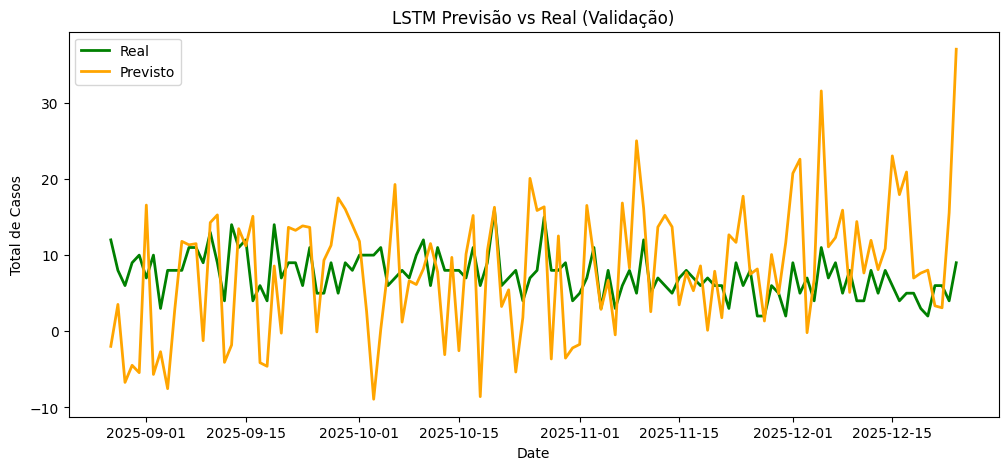

In [77]:
plt.figure(figsize=(12,5))
plt.plot(y_val.index, y_val, label='Real',  color='green', lw=2)
plt.plot(y_val.index, y_pred_val_lstm_, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Previsão vs Real (Validação)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [78]:
metrics_ = dict()
metrics_ = get_erros_metric(y_val, y_pred_val_lstm_, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_val', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,LSTM_val,2025-08-27,2025-12-24,6.848957,75.885637,8.711236,-8.369882,60.000401


In [79]:
y_pred_test_scaled = model_lstm_val.predict(X_test_lstm)
y_pred_test_lstm = scaler_y.inverse_transform(y_pred_test_scaled)
# y_pred_test_lstm = scaler_y_novo.inverse_transform(y_pred_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [80]:
y_pred_test_lstm_ = pd.DataFrame(y_pred_test_lstm, columns=[column_target], index=y_test.index)

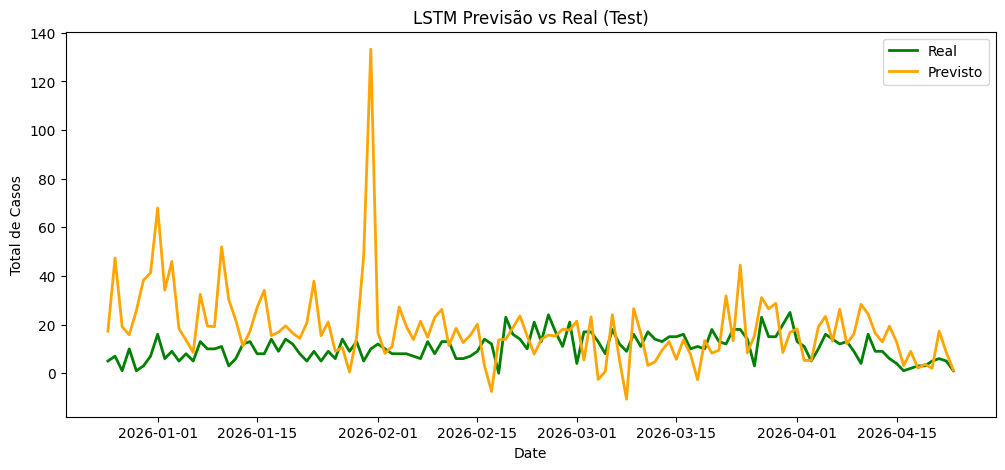

In [81]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_test_lstm_, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Previsão vs Real (Test)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [82]:
metrics_ = dict()
metrics_ = get_erros_metric(y_test, y_pred_test_lstm_, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,LSTM_val,2025-08-27,2025-12-24,6.848957,75.885637,8.711236,-8.369882,60.000401
1,LSTM_test,2025-12-25,2026-04-23,12.029317,346.679681,18.619336,-11.316535,60.000401


In [83]:
# Train + Val
# 1. Unir os dados de Treino e Validação (X e y já escalonados)
X_final_train = np.concatenate((X_train_lstm, X_val_lstm), axis=0)
y_final_train = np.concatenate((y_train_scaled, y_val_scaled), axis=0)

In [84]:
best_epoch = np.argmin(history.history['val_loss']) + 1


# Ajuste do número de épocas (Fator de desconto)
# Se a melhor época foi 50, ele treinará por 40 para evitar o overfit no bloco Val
final_epochs = int(best_epoch * 0.8)

# Reduza as Épocas com um Fator de Desconto
# Treinar o número exato de best_epoch em um conjunto de dados maior quase sempre causa overfitting.
# Uma regra prática de Deep Learning para séries temporais é treinar entre 70% a 80% das épocas originais
# quando adicionamos a validação ao treino, ou aplicar uma taxa de aprendizado menor.

print(f"A melhor performance foi na época: {best_epoch}")
print(f"A melhor performance ajustada foi na época: {final_epochs}")

A melhor performance foi na época: 10
A melhor performance ajustada foi na época: 8


In [85]:
# Re-treinar o modelo com o conjunto completo
model_lstm_agg = lstm_model(X_train_lstm)

In [86]:
# Use o número de épocas que o Early Stopping encontrou anteriormente
start_time = time.time()
history = model_lstm_agg.fit(
    X_final_train, y_final_train,
    epochs=final_epochs, # Ou o melhor valor encontrado pelo early_stop
    batch_size=32,
    verbose=1
    # Sem validation_data aqui, pois você uniu tudo para ganhar poder estatístico
)
end_time = time.time()

Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


67/67 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.3907
Epoch 2/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.2033
Epoch 3/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1775
Epoch 4/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1619
Epoch 5/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1533
Epoch 6/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1458
Epoch 7/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1446
Epoch 8/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1343


In [87]:
# Prever o Teste (O "mundo real" que o modelo nunca viu)
y_pred_test_scaled_final = model_lstm_agg.predict(X_test_lstm)
y_pred_test_final = scaler_y.inverse_transform(y_pred_test_scaled_final)
# y_pred_test_final = scaler_y_novo.inverse_transform(y_pred_test_scaled_final)

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step


In [88]:
y_pred_test_final_ = pd.DataFrame(y_pred_test_final, columns=[column_target], index=y_test.index)

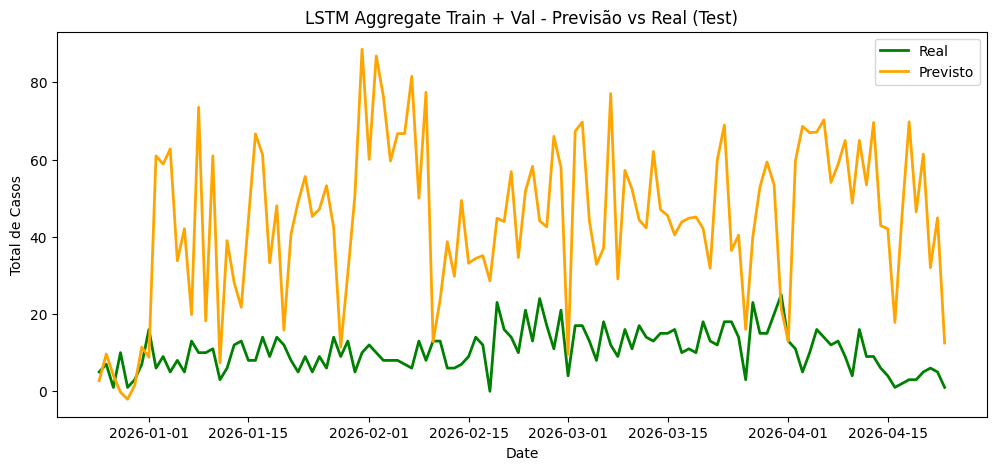

In [89]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_test_final_, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Aggregate Train + Val - Previsão vs Real (Test)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [90]:
metrics_ = dict()
metrics_ = get_erros_metric(y_test, y_pred_test_final_, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test_agg', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,LSTM_val,2025-08-27,2025-12-24,6.848957,75.885637,8.711236,-8.369882,60.000401
1,LSTM_test,2025-12-25,2026-04-23,12.029317,346.679681,18.619336,-11.316535,60.000401
2,LSTM_test_agg,2025-12-25,2026-04-23,34.493567,1557.574423,39.466117,-54.336155,24.244539


In [91]:
# Usando seus dados já devidamente escalados previamente
X_completo = X_final_train
y_completo = y_final_train

tscv = TimeSeriesSplit(n_splits=50, max_train_size=None)
# tscv = TimeSeriesSplit(n_splits=50, max_train_size=365)
fold = 1
fold_losses = []
best_model = None
importancias_acumuladas = []

print("🚀 Iniciando Treino Temporal Inteligente...")

start_time = time.time()
for train_index, val_index in tscv.split(X_completo):
    # Separação estrita baseada na linha do tempo
    X_train_fold, X_val_fold = X_completo[train_index], X_completo[val_index]
    y_train_fold, y_val_fold = y_completo[train_index], y_completo[val_index]

    # Instancia um modelo zerado para este bloco temporal
    model = lstm_model(X_train_fold)

    # ATIVAÇÃO DOS CALLBACKS: Crucial para o modelo não estagnar/viciar
    # callbacks = [
    #     # Se parar de melhorar por 7 épocas, interrompe para não "decorar" a média
    #     EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    #     # Se estagnar, reduz o learning rate para tentar achar padrões locais refinados
    #     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
    # ]

    # Treina usando as variáveis puras (já escaladas por você antes)
    model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=500, # Reduzido ligeiramente o teto para evitar overfit severo
        batch_size=32,
        verbose=1, # Mude para 1 se quiser acompanhar se a perda (loss) está caindo de verdade
        callbacks=callbacks
    )

    val_loss = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    fold_losses.append(val_loss)
    print(f"Fold {fold} - Val Loss (Huber): {val_loss:.4f}")

    # Captura o último fold (o modelo que viu o máximo de histórico possível)
    if fold == tscv.n_splits:
        model_lstm_roll = model

    fold += 1

end_time = time.time()
print("\n--- 📊 FIM DA VALIDAÇÃO CRUZADA ---")
print(f"Média do Huber Loss nos 5 períodos: {np.mean(fold_losses):.4f}")

🚀 Iniciando Treino Temporal Inteligente...
Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 786ms/step - loss: 0.8652 - val_loss: 0.0482 - learning_rate: 0.0010
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.8821 - val_loss: 0.0380 - learning_rate: 0.0010
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.7267 - val_loss: 0.0303 - learning_rate: 0.0010
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.5598 - val_loss: 0.0247 - learning_rate: 0.0010
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.5006 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.5398 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 7/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.4685
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.5210 - val_loss: 0.0126 - learning_rate: 0.0010
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.6297 - val_loss: 0.0107 - learning_rate: 5.0000e-04
Epoch 9/500
3

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - loss: 0.8387 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 2/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.5831 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 3/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.4116 - val_loss: 7.6348e-04 - learning_rate: 0.0010
Epoch 4/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.2820 - val_loss: 1.6994e-04 - learning_rate: 0.0010
Epoch 5/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1956 - val_loss: 2.2072e-04 - learning_rate: 0.0010
Epoch 6/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.1678 - val_loss: 2.8045e-04 - learning_rate: 0.0010
Epoch 7/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1091
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.1103 - val_loss: 2.0256e-04 - learning_rate: 0.0010
Epoch 8/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0951 - val_loss: 5.2339e-04 

In [92]:
y_pred_test_scaled_final = model_lstm_roll.predict(X_test_lstm)
y_pred_test_roll = scaler_y.inverse_transform(y_pred_test_scaled_final)
# y_pred_test_roll = scaler_y_novo.inverse_transform(y_pred_test_scaled_final)

1/4 ━━━━━━━━━━━━━━━━━━━━ 2s 670ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 330ms/step


In [93]:
y_pred_test_final_rolling_window = pd.DataFrame(y_pred_test_roll, columns=[column_target], index=y_test.index)

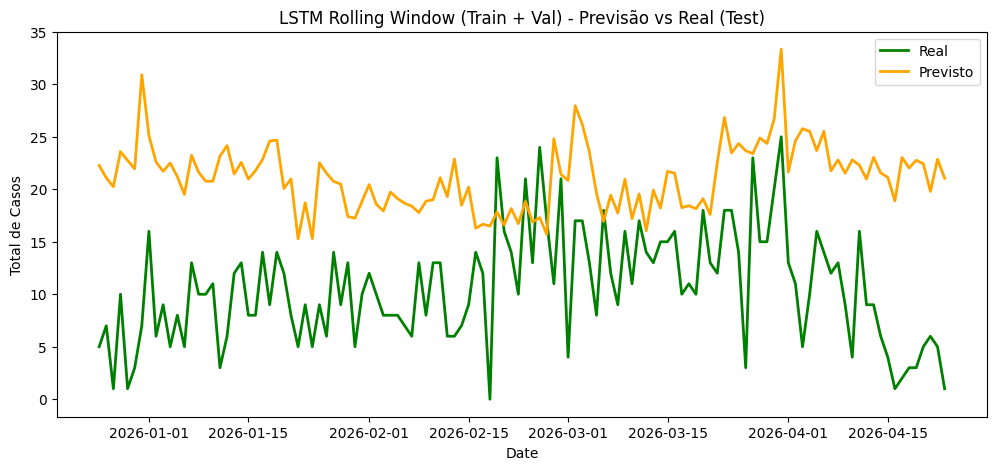

In [94]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_test_final_rolling_window, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Rolling Window (Train + Val) - Previsão vs Real (Test)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [95]:
metrics_ = dict()
metrics_ = get_erros_metric(y_test, y_pred_test_final_rolling_window, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test_rolling', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,LSTM_val,2025-08-27,2025-12-24,6.848957,75.885637,8.711236,-8.369882,60.000401
1,LSTM_test,2025-12-25,2026-04-23,12.029317,346.679681,18.619336,-11.316535,60.000401
2,LSTM_test_agg,2025-12-25,2026-04-23,34.493567,1557.574423,39.466117,-54.336155,24.244539
3,LSTM_test_rolling,2025-12-25,2026-04-23,10.818469,145.295460,12.053857,-4.161931,24.244539


## SHAP

In [96]:
import shap

In [97]:
def interpretability_shap_lstm(model, X_train_model, X_test_model, train_n_lines=None, test_n_lines=None, nsamples=200, feature_names = X_train_scaled.columns.to_list()):
  # Usa pequena amostra para evitar lentidão
  if train_n_lines == None:
    train_n_lines = round(X_train_model.shape[0] / 3)
  if test_n_lines == None:
    test_n_lines = round(X_test_model.shape[0] / 3)

  X_background = X_train_model[:train_n_lines].reshape(train_n_lines, -1)
  X_test_sample = X_test_model[:test_n_lines].reshape(test_n_lines, -1)

  # Função de predição compatível (reconstrói o formato original esperado pelo modelo)
  def model_predict(x, model, X_train_model):
      # Reajusta o formato para (n_amostras, 1, n_features)
      x_reshaped = x.reshape(x.shape[0], 1, X_train_model.shape[2])
      return model.predict(x_reshaped)

  # Cria o KernelExplainer
  explainer = shap.KernelExplainer(lambda x: model_predict(x, model, X_train_model), X_background)

  # Calcula valores SHAP
  shap_values = explainer.shap_values(X_test_sample, nsamples=nsamples)

  # Flatten das X_test_model
  X_test_plot = X_test_model[:test_n_lines].reshape(test_n_lines, -1)
  shap_plot = shap_values.reshape(test_n_lines, -1)

  # Visualiza a importância média das features
  shap.summary_plot(shap_plot, X_test_plot, feature_names=feature_names)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


  0%|          | 0/40 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━

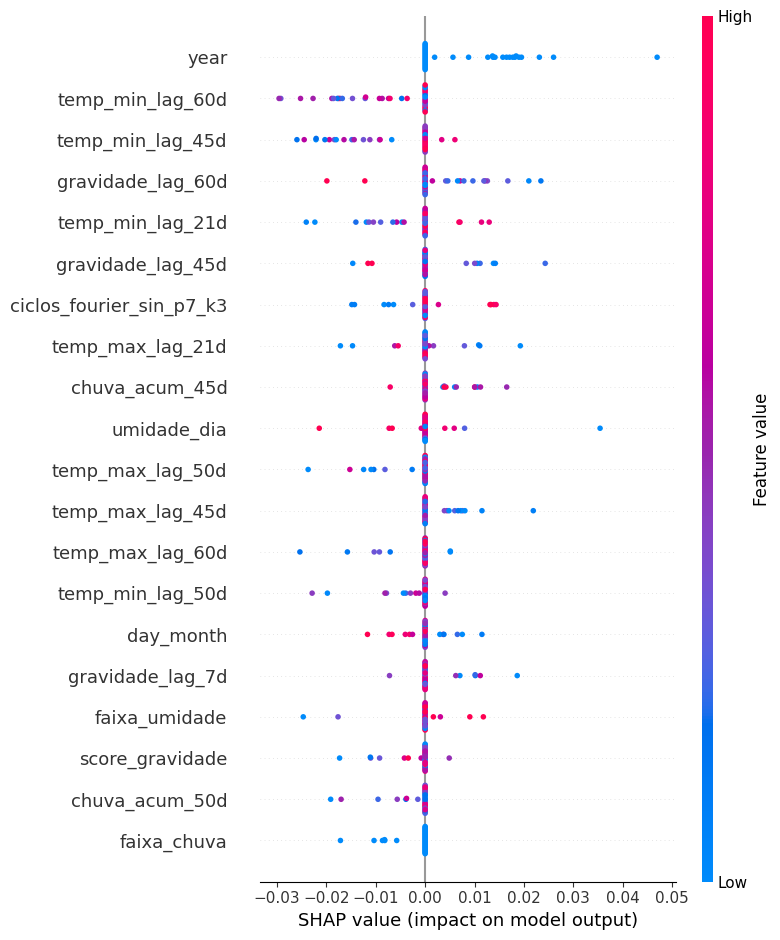

In [98]:
# VAL
interpretability_shap_lstm(model_lstm_val, X_train_lstm, X_val_lstm, nsamples=200, feature_names = X_train_scaled.columns.to_list())

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


  0%|          | 0/40 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step
1/1 ━━━━━━━━━━━━

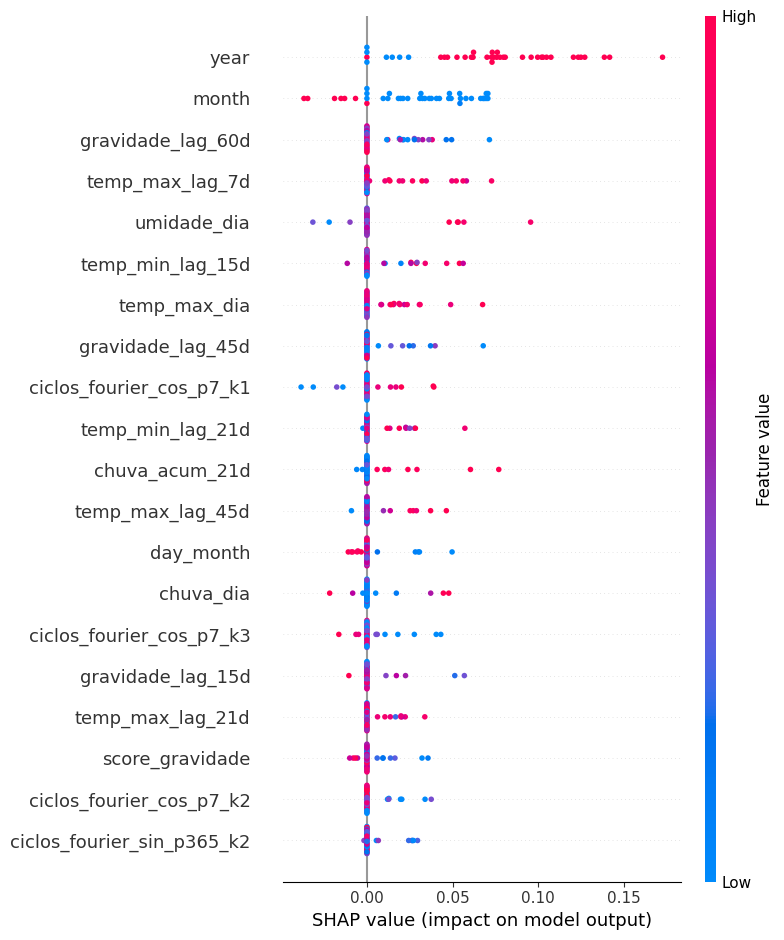

In [99]:
# Test Agg
interpretability_shap_lstm(model_lstm_agg, X_final_train, X_test_lstm, nsamples=200, feature_names = X_train_scaled.columns.to_list())

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


  0%|          | 0/40 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step
1/1 ━━━━━━━━━━

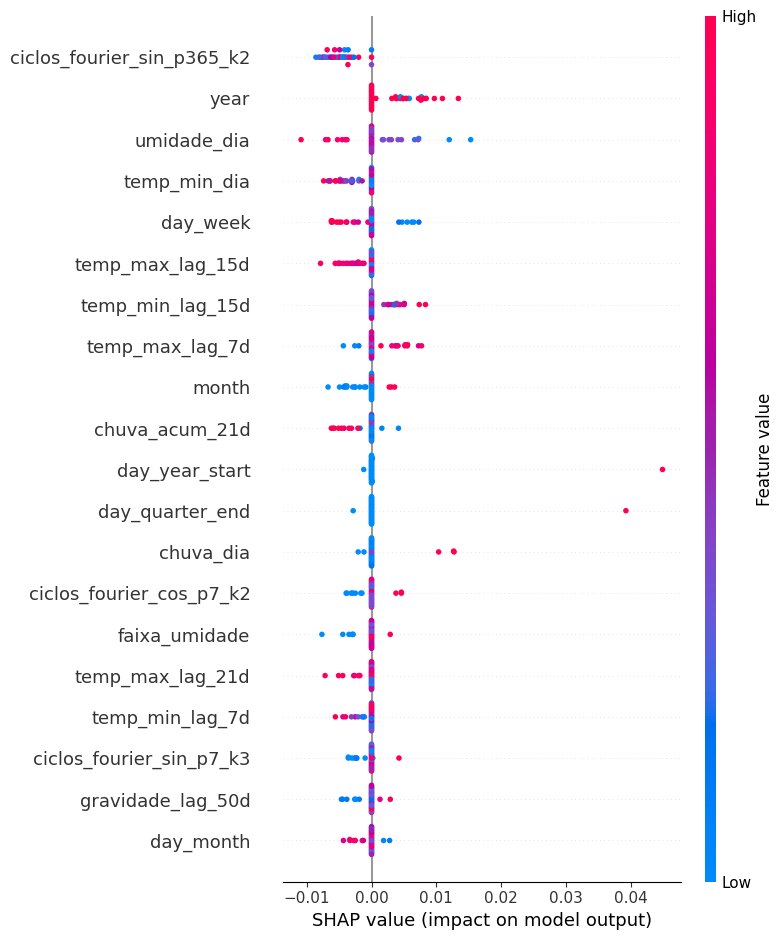

In [101]:
# Test Rolling
interpretability_shap_lstm(model_lstm_roll, X_final_train, X_test_lstm, nsamples=200, feature_names = X_train_scaled.columns.to_list())